Exploratory Data Analysis - Content Refresh Dataset
<br>

Project- Forecasting future content growth and recovery using historical using Historical Search Intelligence signals

</br>


In [1]:
# importing libraries and setup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

# display settings
pd.set_option('display.max_columns',100)
pd.set_option('display.width',160)
pd.set_option('display.float_format', lambda x: f"{x:,.3f}")

sns.set_style('whitegrid')
plt.rcParams['figure.dpi']=110
%matplotlib inline

# CSV path
CSV_PATH="../../data/raw/content_refresh_anonymized.csv"

1. data overview 

In [2]:
#loading
df=pd.read_csv(CSV_PATH)

print("SHAPE (rows,columns):",df.shape)

print("\n ---column names & Dtypes---")
print(df.dtypes)

SHAPE (rows,columns): (30000, 44)

 ---column names & Dtypes---
content_id                 object
client_id                  object
search_volume             float64
competition               float64
competition_level          object
cpc                       float64
content_type               object
main_intent                object
word_count                float64
char_count                float64
provider_used              object
model_used                 object
impressions_90d             int64
clicks_90d                  int64
pageviews_90d               int64
sessions_90d                int64
users_90d                   int64
engaged_sessions_90d        int64
ai_sessions_90d             int64
scroll_events_90d           int64
days_with_impressions       int64
days_with_sessions          int64
impressions_last_30d        int64
clicks_last_30d             int64
sessions_last_30d           int64
impressions_prev_30d        int64
clicks_prev_30d             int64
sessions_prev_30d 

In [3]:
df.head(3).T

,0,1,2
content_id,content_304f48230142,content_a1fb4e703a9e,content_9aa793d4d895
client_id,client_f369cb89fc,client_4e07408562,client_7f2253d7e2
search_volume,10.000,90.000,0.000
competition,0.670,0.010,0.000
competition_level,HIGH,LOW,LOW
cpc,2.050,0.050,0.000
content_type,keyword article,keyword article,keyword article
main_intent,transactional,informational,informational
word_count,"3,221.000","2,481.000","3,515.000"
char_count,"20,457.000","15,562.000","23,643.000"


In [4]:
# missing values- count + percentage, sorted by how bad they are
missing=df.isnull().sum()
missing_pct=(missing / len(df) * 100).round(2)
missing_df=pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_df=missing_df[missing_df["missing_count"] > 0].sort_values("missing_pct", ascending=False)
missing_df

,missing_count,missing_pct
provider_used,21438,71.460
word_count_tier,7699,25.660
char_count,7699,25.660
word_count,7699,25.660
char_count_tier,7699,25.660
model_used,5733,19.110
trend_pct,3388,11.290
competition_level,2610,8.700
search_volume,2468,8.230
competition,2468,8.230


In [5]:
#duplicate check: full row duplicates and duplicate ids
print('Full row duplicates:', df.duplicated().sum())
print('duplicate content_id:', df['content_id'].duplicated().sum())
print('unique content_id:', df['content_id'].nunique())
print('unique client id:', df['client_id'].nunique())

Full row duplicates: 0
duplicate content_id: 0
unique content_id: 30000
unique client id: 32


2. Descriptive Statistics

> Getting central tendency, spread, and range for every numeric column and frequency counts for every categorical column.

In [6]:
# spliting columns into numeric vs categorical buckets

numeric_cols=df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols=df.select_dtypes(include=['object']).columns.tolist()

print('Numerical columns:', numeric_cols)
print('\n Categorical columns:', categorical_cols)

Numerical columns: ['search_volume', 'competition', 'cpc', 'word_count', 'char_count', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier_order', 'days_since_last_update', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'trend_pct']

 Categorical columns: ['content_id', 'client_id', 'competition_level', 'content_type', 'main_intent', 'provider_used', 'model_used', 'age_tier', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'impression_tier', 'position_tier', 'trend_direction']


In [7]:
desc=df[numeric_cols].describe().T
desc['skew']=df[numeric_cols].skew()
desc['missing_pct']=(df[numeric_cols].isnull().sum() / len(df)*100).round(2)
desc

,count,mean,std,min,25%,50%,75%,max,skew,missing_pct
search_volume,"27,532.000",158.882,"1,518.271",0.000,0.000,10.000,20.000,"74,000.000",26.016,8.230
competition,"27,532.000",0.147,0.285,0.000,0.000,0.000,0.130,1.000,2.044,8.230
cpc,"27,532.000",0.485,2.102,0.000,0.000,0.000,0.000,100.360,13.738,8.230
word_count,"22,301.000","3,107.760","1,452.383",8.000,"2,413.000","2,877.000","3,666.000","9,546.000",0.938,25.660
char_count,"22,301.000","20,665.278","10,115.344",40.000,"15,644.000","19,116.000","24,011.000","111,158.000",1.551,25.660
impressions_90d,"30,000.000","5,200.366","16,838.020",1.000,81.000,731.000,"3,615.250","517,715.000",11.385,0.000
clicks_90d,"30,000.000",16.097,75.077,0.000,0.000,1.000,7.000,"4,178.000",18.346,0.000
pageviews_90d,"30,000.000",49.942,152.101,0.000,2.000,8.000,33.000,"5,998.000",10.861,0.000
sessions_90d,"30,000.000",37.067,107.069,1.000,2.000,7.000,27.000,"4,345.000",12.127,0.000
users_90d,"30,000.000",35.938,103.748,1.000,2.000,7.000,27.000,"4,913.000",13.101,0.000


In [8]:
# categorical value counts(skipping content_id/client_id, these are ids not categories)
for col in categorical_cols:
    if col in ("content_id", "client_id"):
        continue
    vc = df[col].value_counts(dropna=False)
    vc_pct = (vc/len(df)*100).round(1)
    print(f"\n{col} (n_unique={df[col].nunique()}):")
    display(pd.DataFrame({"count": vc, "pct": vc_pct}))


competition_level (n_unique=3):


,count,pct
competition_level,,
LOW,22896,76.300
HIGH,2658,8.900
NaN,2610,8.700
MEDIUM,1836,6.100



content_type (n_unique=3):


,count,pct
content_type,,
keyword article,27207,90.700
feedly article,2096,7.000
comparison article,697,2.300



main_intent (n_unique=4):


...

,count,pct
impression_tier,,
low,11248,37.500
moderate,10469,34.900
good,7205,24.000
excellent,1078,3.600



position_tier (n_unique=5):


,count,pct
position_tier,,
page_1,11814,39.400
striking,7304,24.300
page_3_5,7242,24.100
top_3,2321,7.700
deep,1319,4.400



trend_direction (n_unique=5):


,count,pct
trend_direction,,
down,16262,54.200
stable,5962,19.900
up,4388,14.600
new,2236,7.500
flat,1152,3.800


3. Target variable deep dive(trend_pct)

> For this forecasting project, trend_pct and its categorical sibling trend_direction is the key target.

In [9]:
print('---trend_pct basic stats---')
print(df['trend_pct'].describe())

---trend_pct basic stats---
count   26,612.000
mean        -4.786
std        473.862
min       -100.000
25%        -62.600
50%        -33.500
75%          0.000
max     44,900.000
Name: trend_pct, dtype: float64


In [10]:
df.T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,...,29950,29951,29952,29953,29954,29955,29956,29957,29958,29959,29960,29961,29962,29963,29964,29965,29966,29967,29968,29969,29970,29971,29972,29973,29974,29975,29976,29977,29978,29979,29980,29981,29982,29983,29984,29985,29986,29987,29988,29989,29990,29991,29992,29993,29994,29995,29996,29997,29998,29999
content_id,content_304f48230142,content_a1fb4e703a9e,content_9aa793d4d895,content_331d6c4de07b,content_d99b7a2d90ca,content_d4084a4bc775,content_9a34b442b552,content_a63219c6e95a,content_5e6c160719bc,content_c27558df2b0c,content_d8ee6cc6d642,content_5a3e876cf7f7,content_42fb2cad9ecf,content_a5a2fbc76336,content_91067a14431a,content_689414059706,content_78bd1d4a1d4d,content_761a44afda12,content_0b360eb9db55,content_af865035b328,content_0d748c484ab1,content_9d548144b06d,content_3fb46bec4413,content_2da6ae9d0882,content_0e23e310d404,content_033ae3e7aecf,content_72c5c2d73e5a,content_7ea135180dd9,content_19ad8f9bac29,content_ba8e51f13800,content_249298388b45,content_24ee79621dbf,content_5eeba5d398f2,content_d87a116e2c79,content_55f75c034970,content_1a28b25c7128,content_bce275871a25,content_724a2783045d,content_dbe82879a406,content_4595e8704e07,content_4df0b7207fe3,content_e45a618f6b32,content_3223b1640f5a,content_1938955b34c4,content_793b7376a0e5,content_2a6383ed421f,content_c59d46264834,content_40cb4af260c0,content_326fa2fa449f,content_f0717373e86e,...,content_7d52e164c23c,content_b018d113bdaf,content_e6cc2aad65ea,content_ac21791a5807,content_5daabd0e31f3,content_a31cad37ea8a,content_20decd85a0c2,content_3b806fcc5b2c,content_d6ce4e17f464,content_73cf70f08e06,content_b1d45033b059,content_326a540b3a6e,content_be106cd29636,content_7ba9b154acf6,content_07ea0872b973,content_a3af3b8346d8,content_77867ed726e1,content_b9e02bd01a73,content_179533212cd0,content_b5db993ce36a,content_4998a1c76243,content_92a5d2709aa9,content_1db0d204d42f,content_4be930227848,content_b00f10211e25,content_bdee2164f576,content_851c604b0631,content_c87291853cab,content_3dc420aa9809,content_6f2f3043b633,content_81a91fe32bc2,content_2dfd17269502,content_fe5d259e6bc5,content_6880eb215048,content_a6568a7c07d7,content_fcad8c75dc44,content_677c622c0bfb,content_7b36d6ffe9bd,content_9bb9a0584cae,content_e859812ce999,content_b7fa2d76e5ae,content_04a7a1b7b5ec,content_23dce6a656e6,content_9bd30342fd4a,content_995627a1f490,content_c322796023c8,content_526572edb3fa,content_38112bdd0c6e,content_ab26273a7e7a,content_887020f20b5e
client_id,client_f369cb89fc,client_4e07408562,client_7f2253d7e2,client_19581e27de,client_3fdba35f04,client_f369cb89fc,client_8722616204,client_19581e27de,client_6208ef0f77,client_19581e27de,client_19581e27de,client_d4735e3a26,client_6208ef0f77,client_8527a891e2,client_6208ef0f77,client_9f14025af0,client_6208ef0f77,client_19581e27de,client_349c41201b,client_f369cb89fc,client_f369cb89fc,client_6208ef0f77,client_4e07408562,client_e629fa6598,client_19581e27de,client_f369cb89fc,client_4e07408562,client_4ec9599fc2,client_3fdba35f04,client_d59eced1de,client_2c624232cd,client_19581e27de,client_bbb965ab0c,client_19581e27de,client_d029fa3a95,client_6208ef0f77,client_f369cb89fc,client_4e07408562,client_6208ef0f77,client_8527a891e2,client_9f14025af0,client_7f2253d7e2,client_a88a7902cb,client_f369cb89fc,client_8527a891e2,client_7f2253d7e2,client_19581e27de,client_f369cb89fc,client_98a3ab7c34,client_8527a891e2,...,client_8527a891e2,client_7f2253d7e2,client_19581e27de,client_19581e27de,client_6208ef0f77,client_8b940be7fb,client_6208ef0f77,client_6208ef0f77,client_f369cb89fc,client_19581e27de,client_e29c9c180c,client_8527a891e2,client_d029fa3a95,client_19581e27de,client_2c624232cd,client_25fc0e7096,client_19581e27de,client_2c624232cd,client_f74efabef1,client_6208ef0f77,client_f369cb89fc,client_25fc0e7096,client_6208ef0f77,client_d4735e3a26,client_3fdba35f04,client_6208ef0f77,client_6208ef0f77,client_d029fa3a95,client_7f2253d7e2,clie

In [11]:
"""Reverse engineer the formula behind the trend_pct by reconstructing it from sessions, clicks, and impressions separately, then checking which one matches exactly. this is crucial before building forecasting features"""

tmp=df.copy()

tmp["recon_sessions"]=np.where(tmp["sessions_prev_30d"] > 0, (tmp['sessions_last_30d'] - tmp['sessions_prev_30d']) / tmp['sessions_prev_30d'] * 100, np.nan)

tmp["recon_clicks"] = np.where(tmp["clicks_prev_30d"] > 0,(tmp["clicks_last_30d"] - tmp["clicks_prev_30d"]) / tmp["clicks_prev_30d"] * 100,np.nan,
)

tmp["recon_impressions"] = np.where(tmp["impressions_prev_30d"] > 0,(tmp["impressions_last_30d"] - tmp["impressions_prev_30d"]) / tmp["impressions_prev_30d"] * 100,np.nan,
)

for label, col in [("sessions","recon_sessions"),("clicks","recon_clicks"),("impressions","recon_impressions")]:
    comp = tmp[["trend_pct",col]].dropna()
    diff = (comp['trend_pct'] - comp[col]).abs()
    match_rate = (diff < 1.0).mean()*100
    print(f"reconstructed from {label:12s} -> match rate within 1.0: {match_rate:6.1f}% (n={len(comp)})")


reconstructed from sessions     -> match rate within 1.0:    4.1% (n=21873)
reconstructed from clicks       -> match rate within 1.0:    1.4% (n=11759)
reconstructed from impressions  -> match rate within 1.0:  100.0% (n=26612)


# from the above observation 
> we can conclude that trend_pct is calculated from IMPRESSIONS (100% exact match) 
>
> i used trend_pct = (impressions_last_30d - impressions_prev_30d) / impressions_prev_30d * 100
>
> this means trend_pct reflects SEARCH VISIBILITY change, not actual
>


In [12]:
# why is trend_pct missing for 11% of rows? checking if its a division by zero issue

missing_trend = df[df['trend_pct'].isnull()]
print('rows with missing trend_pct:', len(missing_trend))
print(missing_trend[['clicks_prev_30d', 'sessions_prev_30d','impressions_prev_30d']].describe())
print("\n% of missing-trend rows where impressions_prev_30d == 0:",
(missing_trend["impressions_prev_30d"] == 0).mean() * 100)

rows with missing trend_pct: 3388
       clicks_prev_30d  sessions_prev_30d  impressions_prev_30d
count        3,388.000          3,388.000             3,388.000
mean             0.000              0.743                 0.000
std              0.000              2.084                 0.000
min              0.000              0.000                 0.000
25%              0.000              0.000                 0.000
50%              0.000              0.000                 0.000
75%              0.000              1.000                 0.000
max              0.000             69.000                 0.000

% of missing-trend rows where impressions_prev_30d == 0: 100.0


> there are around 3388 rows which has null value in trend_pct feature

In [13]:
# trend_direction vs trend_pct range -- confirms the labeling thresholds
df.groupby("trend_direction")["trend_pct"].agg(["count", "min", "median", "max"])

,count,min,median,max
trend_direction,,,,
down,16262,-100.000,-55.600,-20.000
flat,0,NaN,NaN,NaN
new,0,NaN,NaN,NaN
stable,5962,-20.000,-3.800,20.000
up,4388,20.000,62.550,"44,900.000"


In [14]:
# Outlier check: extreme trend_pct values usually come from a tiny denominator
# (e.g. prev=1, last=50 gives +4900%) -- a classic "small base effect".
# This is important to flag since raw % trend is unstable at low volume.
extreme = df[(df["trend_pct"] > 1000) | (df["trend_pct"] < -100)]
print("Extreme trend_pct rows (>1000% or <-100%):", len(extreme), f"({len(extreme)/len(df)*100:.2f}% of data)")

low_base_extreme = extreme[extreme["impressions_prev_30d"] <= 3]
print(f"% of extreme trend rows where impressions_prev_30d <= 3: {len(low_base_extreme)/len(extreme)*100:.1f}%")

extreme[["impressions_prev_30d", "impressions_last_30d", "trend_pct"]].sort_values("trend_pct", ascending=False).head(10)

Extreme trend_pct rows (>1000% or <-100%): 83 (0.28% of data)
% of extreme trend rows where impressions_prev_30d <= 3: 37.3%


,impressions_prev_30d,impressions_last_30d,trend_pct
24695,1,450,"44,900.000"
15405,757,212015,"27,907.300"
14549,9,2364,"26,166.700"
3561,1,215,"21,400.000"
19697,9,1546,"17,077.800"
24726,8,1274,"15,825.000"
9097,1,150,"14,900.000"
27305,4,470,"11,650.000"
1132,3,341,"11,266.700"
19525,2,227,"11,250.000"


4. Correlation Analysis 

> measure linear (pearson) and rank based(spearman) relationships between the numeric search intelligence signals and target is trend_pct. 

> spearman here matters because the trend_pct is heavily skewed and non linear and pearson alone would understate real monotonic relationships

> we also flag highly correlated feature pairs to catch multicollinearity before feature selection


In [15]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
target = "trend_pct"

pearson_corr = df[numeric_cols].corr(method="pearson")[target].drop(target).sort_values(key=abs, ascending=False)
spearman_corr = df[numeric_cols].corr(method="spearman")[target].drop(target).sort_values(key=abs, ascending=False)

combo = pd.DataFrame({"pearson": pearson_corr, "spearman": spearman_corr})
combo

,pearson,spearman
age_tier_order,0.001,0.230
ai_sessions_90d,-0.003,0.037
ai_traffic_pct,-0.004,0.034
avg_position,0.047,0.077
char_count,-0.007,0.044
clicks_90d,-0.002,0.176
clicks_last_30d,0.006,0.229
clicks_prev_30d,-0.004,0.143
competition,0.014,0.018
content_age_days,0.001,0.216


In [16]:
# full correlation matrix (spearman -- more robust)
# multicollinearity check among candidate predictor features

full_corr = df[numeric_cols].corr(method="spearman")

# flag highly correlated feature pairs (|corr|>0.85)
# and one of each pair is likely be dropped before modelling

pairs = []
cols = full_corr.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        c = full_corr.iloc[i, j]
        if abs(c) > 0.85:
            pairs.append((cols[i], cols[j], round(c, 3)))

pairs_df = pd.DataFrame(pairs, columns=["feature_1", "feature_2", "spearman_corr"]).sort_values(
    "spearman_corr", key=abs, ascending=False
)
pairs_df

,feature_1,feature_2,spearman_corr
17,ai_sessions_90d,ai_traffic_pct,0.999
11,sessions_90d,users_90d,0.999
7,pageviews_90d,sessions_90d,0.992
8,pageviews_90d,users_90d,0.991
14,users_90d,days_with_sessions,0.979
12,sessions_90d,days_with_sessions,0.979
3,impressions_90d,impressions_prev_30d,0.974
9,pageviews_90d,days_with_sessions,0.972
0,word_count,char_count,0.971
16,engaged_sessions_90d,engagement_rate,0.966


5. Key Visualizations

> in the above observations the patterns is skewed/high cardinality data are much easier to plot

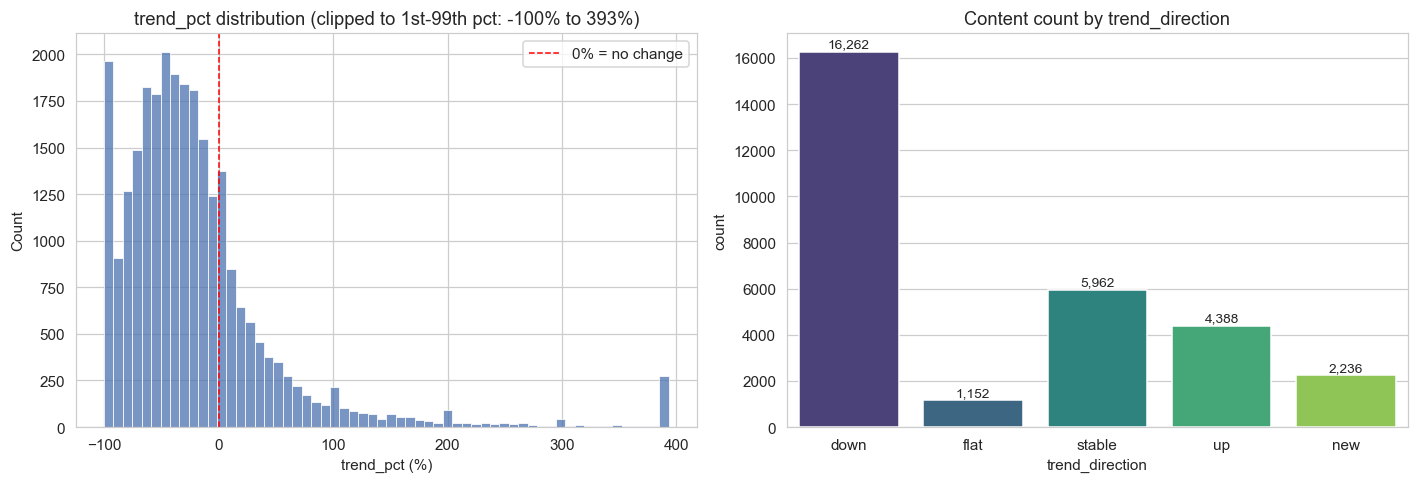

In [17]:
# 1. Target distribution: raw is unreadable because of extreme outliers found
# in Step 3, so we clip to the 1st-99th percentile JUST for visualization
# (the underlying data itself is untouched).
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

clip_lo, clip_hi = df["trend_pct"].quantile([0.01, 0.99])
clipped = df["trend_pct"].clip(clip_lo, clip_hi)
sns.histplot(clipped.dropna(), bins=60, ax=axes[0], color="#4C72B0")
axes[0].set_title(f"trend_pct distribution (clipped to 1st-99th pct: {clip_lo:.0f}% to {clip_hi:.0f}%)")
axes[0].set_xlabel("trend_pct (%)")
axes[0].axvline(0, color="red", linestyle="--", linewidth=1, label="0% = no change")
axes[0].legend()

order = ["down", "flat", "stable", "up", "new"]
counts = df["trend_direction"].value_counts().reindex(order)
sns.barplot(x=counts.index, y=counts.values, hue=counts.index, ax=axes[1], palette="viridis", legend=False)
axes[1].set_title("Content count by trend_direction")
axes[1].set_ylabel("count")
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 200, f"{v:,}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()


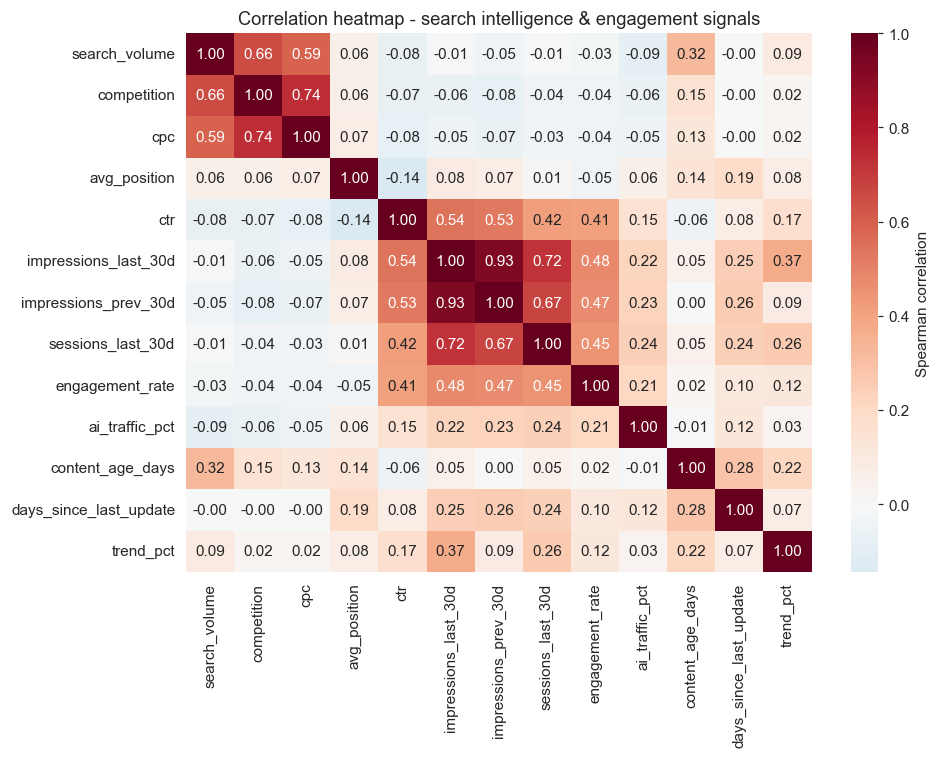

In [18]:
# 2. Correlation heatmap of a curated set of key features (the full 30-column
# matrix would be unreadable, so we pick the most relevant "search
# intelligence" + engagement signals).
key_cols = [
    "search_volume", "competition", "cpc", "avg_position", "ctr",
    "impressions_last_30d", "impressions_prev_30d", "sessions_last_30d",
    "engagement_rate", "ai_traffic_pct", "content_age_days",
    "days_since_last_update", "trend_pct",
]
corr = df[key_cols].corr(method="spearman")
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
            cbar_kws={"label": "Spearman correlation"})
ax.set_title("Correlation heatmap - search intelligence & engagement signals")
plt.tight_layout()
plt.show()

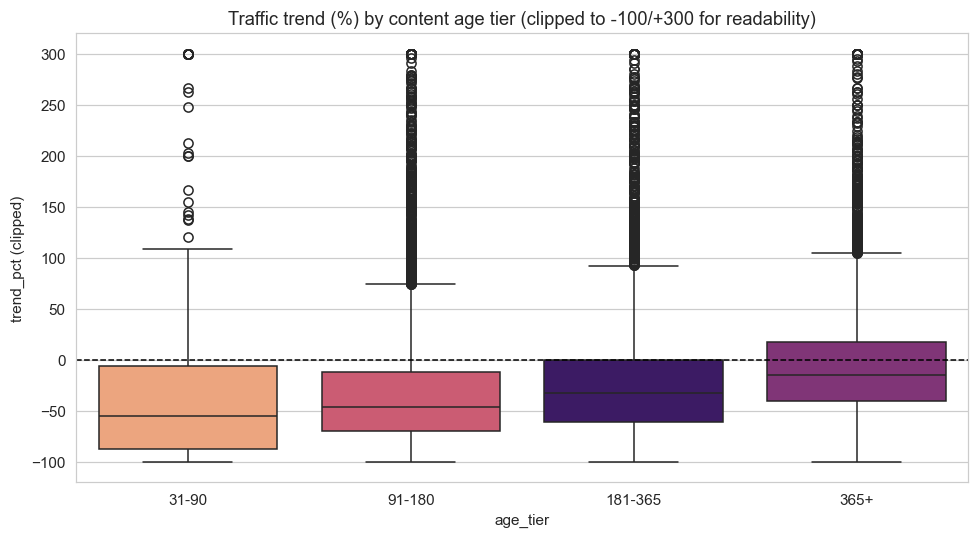

In [19]:
# 3. Content age vs trend_pct -- does older content decay more?
fig, ax = plt.subplots(figsize=(9, 5))
age_order = ["31-90", "91-180", "181-365", "365+"]
plot_df = df.copy()
plot_df["trend_pct_clipped"] = plot_df["trend_pct"].clip(-100, 300)  # visual clip only
sns.boxplot(data=plot_df, x="age_tier", y="trend_pct_clipped", hue="age_tier",
            order=age_order, ax=ax, palette="magma", legend=False)
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Traffic trend (%) by content age tier (clipped to -100/+300 for readability)")
ax.set_ylabel("trend_pct (clipped)")
plt.tight_layout()
plt.show()

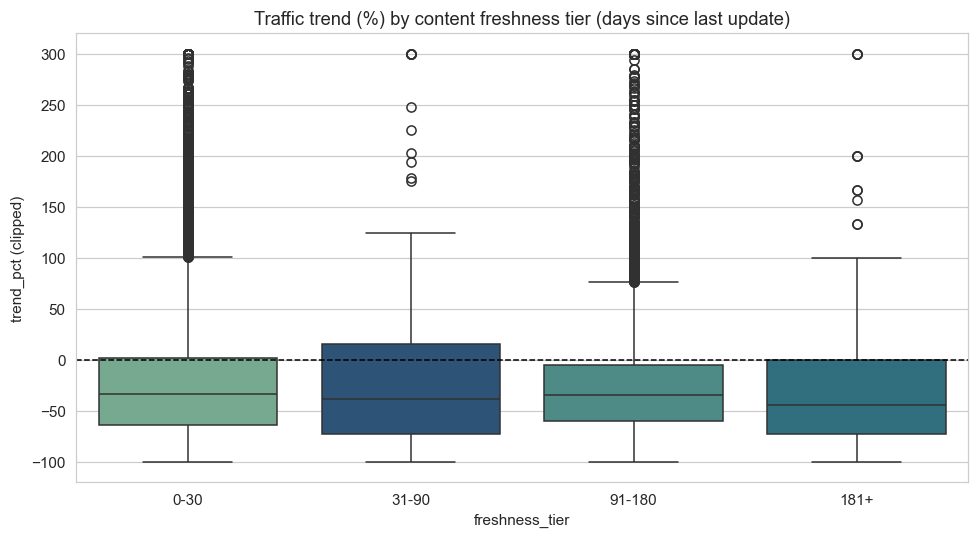

In [20]:
# 4. Freshness tier (days since last content update) vs trend -- directly
# relevant to "recovery" framing: does refreshing old content correlate
# with improved trend?
fig, ax = plt.subplots(figsize=(9, 5))
fresh_order = ["0-30", "31-90", "91-180", "181+"]
sns.boxplot(data=plot_df, x="freshness_tier", y="trend_pct_clipped", hue="freshness_tier",
            order=fresh_order, ax=ax, palette="crest", legend=False)
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Traffic trend (%) by content freshness tier (days since last update)")
ax.set_ylabel("trend_pct (clipped)")
plt.tight_layout()
plt.show()

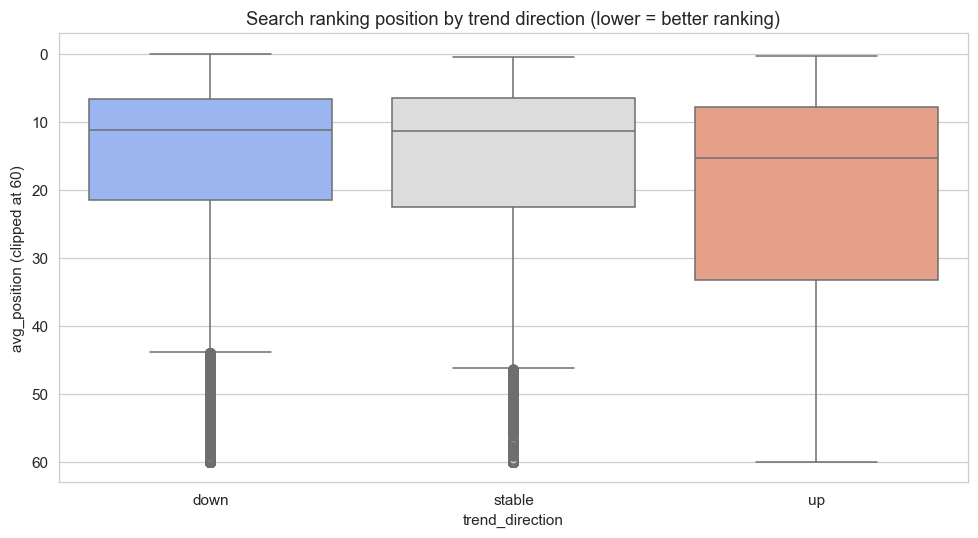

In [21]:
# 5. avg_position (Google ranking position) vs trend_direction -- does
# ranking position predict growth/decline?
fig, ax = plt.subplots(figsize=(9, 5))
dir_order = ["down", "stable", "up"]
plot_df2 = df[df["trend_direction"].isin(dir_order)].copy()
plot_df2["avg_position_clipped"] = plot_df2["avg_position"].clip(0, 60)
sns.boxplot(data=plot_df2, x="trend_direction", y="avg_position_clipped", hue="trend_direction",
            order=dir_order, ax=ax, palette="coolwarm", legend=False)
ax.set_title("Search ranking position by trend direction (lower = better ranking)")
ax.set_ylabel("avg_position (clipped at 60)")
ax.invert_yaxis()  # position 1 = top, so invert to make "better" appear higher
plt.tight_layout()
plt.show()

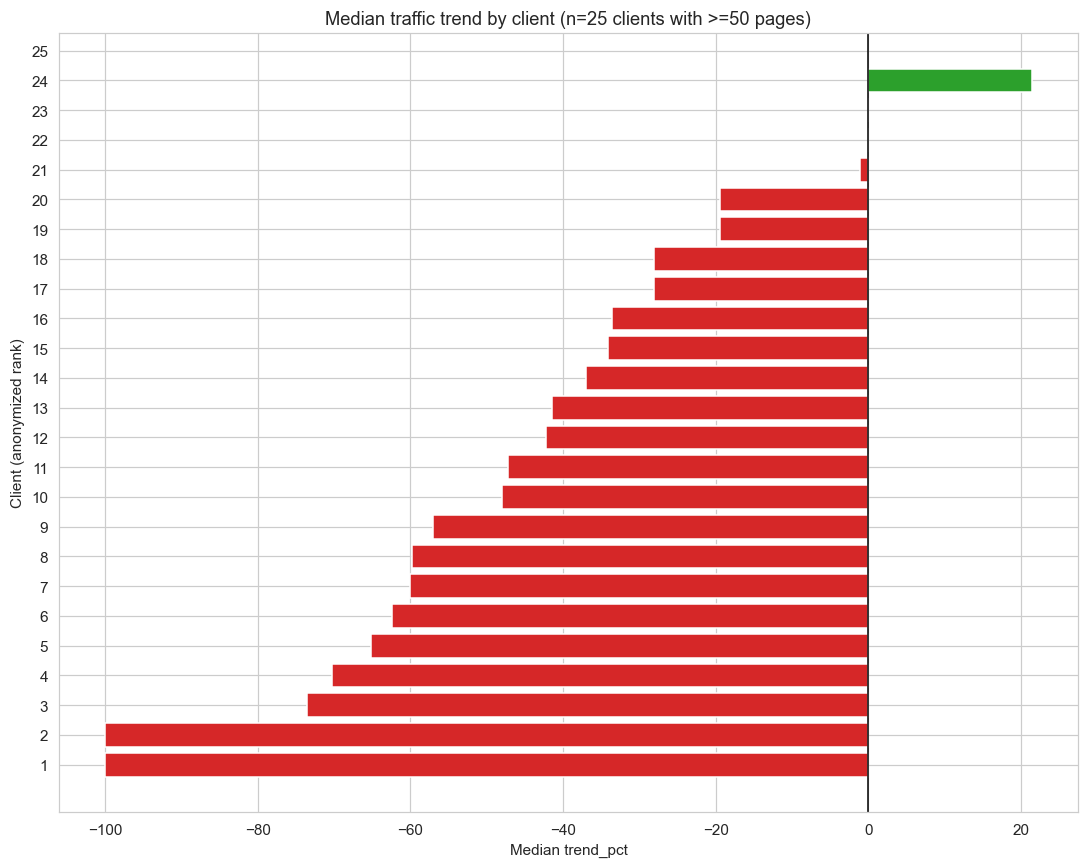

In [22]:
# 6. Client-level variation -- median trend_pct per client. Important for
# the forecasting model: is growth/decline a CLIENT-level (site-wide)
# phenomenon vs a content-level one? Do we need client as a feature?
client_stats = (
    df.groupby("client_id")
    .agg(n_content=("content_id", "count"), median_trend=("trend_pct", "median"))
    .query("n_content >= 50")  # only clients with enough content to be meaningful
    .sort_values("median_trend")
)
fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#d62728" if v < 0 else "#2ca02c" for v in client_stats["median_trend"]]
ax.barh(range(len(client_stats)), client_stats["median_trend"], color=colors)
ax.set_yticks(range(len(client_stats)))
ax.set_yticklabels([f"{i+1}" for i in range(len(client_stats))])  # anonymize labels as rank
ax.set_xlabel("Median trend_pct")
ax.set_ylabel("Client (anonymized rank)")
ax.axvline(0, color="black", linewidth=1)
ax.set_title(f"Median traffic trend by client (n={len(client_stats)} clients with >=50 pages)")
plt.tight_layout()
plt.show()

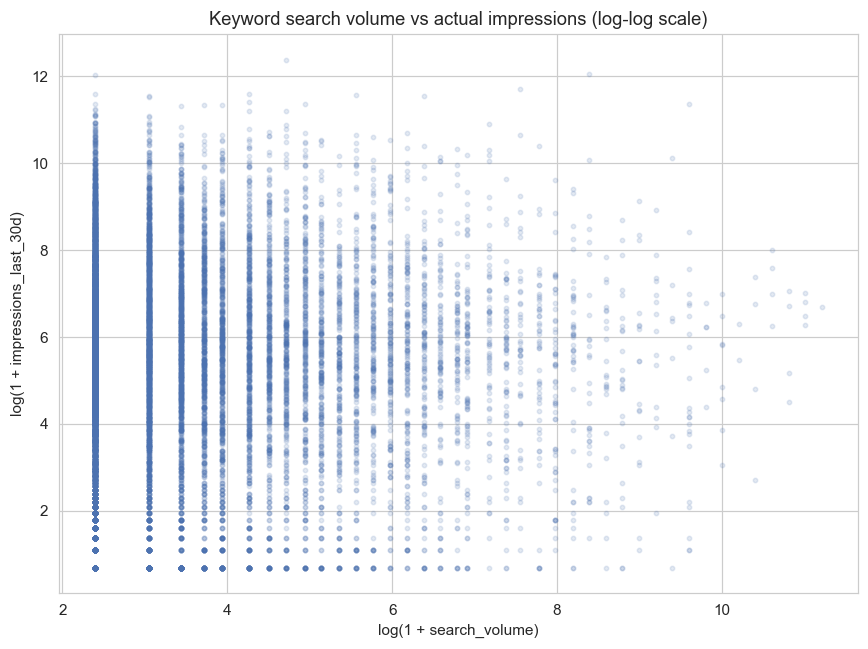

In [23]:
# 7. Search volume vs current impressions (log-log) -- sanity check of
# whether declared keyword search_volume actually predicts real impressions;
# a key "search intelligence" signal.
fig, ax = plt.subplots(figsize=(8, 6))
plot_df3 = df[(df["search_volume"] > 0) & (df["impressions_last_30d"] > 0)]
ax.scatter(
    np.log1p(plot_df3["search_volume"]),
    np.log1p(plot_df3["impressions_last_30d"]),
    alpha=0.15, s=8, color="#4C72B0",
)
ax.set_xlabel("log(1 + search_volume)")
ax.set_ylabel("log(1 + impressions_last_30d)")
ax.set_title("Keyword search volume vs actual impressions (log-log scale)")
plt.tight_layout()
plt.show()

6. Data quality flags and the recommendations for the forecasting capstone

In [24]:
report = []

report.append("1. MISSING DATA TO HANDLE BEFORE MODELING")
report.append("   - provider_used: 71% missing -> likely 'not tracked' rather than random;")
report.append("     treat missing as its own category ('unknown'), don't drop the column.")
report.append("   - word_count/char_count/word_count_tier/char_count_tier: ~26% missing,")
report.append("     all missing TOGETHER (same rows) -> content where text metadata wasn't")
report.append("     captured. Consider a binary 'has_word_count_data' flag.")
report.append("   - search_volume/competition/cpc: ~8% missing together -> keyword data")
report.append("     not available for that content; impute 0 or flag separately -- these")
report.append("     are core 'search intelligence' inputs so missingness itself may be")
report.append("     predictive (e.g. no assigned keyword = weaker baseline visibility).")
report.append("   - trend_pct: 11.3% missing, caused by prev_30d impressions = 0")
report.append("     (division by zero). These rows are NOT random -- mostly brand-new or")
report.append("     dormant content. For a 'recovery' model these may need a separate")
report.append("     'no prior baseline' class rather than deletion.")
report.append("")

report.append("2. TARGET VARIABLE (trend_pct) QUALITY ISSUES")
report.append("   - Confirmed formula: (impressions_last_30d - impressions_prev_30d)")
report.append("     / impressions_prev_30d * 100 -- an IMPRESSIONS/visibility metric,")
report.append("     not a sessions/clicks metric. Keep this distinction clear when")
report.append("     defining what 'growth' means for your forecast target.")
report.append("   - Extremely skewed (skew~57) with a max of 44,900% caused by a")
report.append("     'small base effect' (prev_30d impressions near 0).")
report.append("   - RECOMMENDATION: clip/winsorize the target (e.g. to [-100, 500]) or")
report.append("     model log1p(impressions_last_30d) - log1p(impressions_prev_30d).")
report.append("     Alternatively, frame as classification using trend_direction.")
report.append("")

report.append("3. REDUNDANT FEATURES (Spearman > 0.85, pick one per group)")
report.append("   - sessions_90d ~ users_90d ~ pageviews_90d ~ days_with_sessions")
report.append("   - ai_sessions_90d ~ ai_traffic_pct")
report.append("   - impressions_90d ~ impressions_prev_30d ~ impressions_last_30d ~ days_with_impressions")
report.append("   - word_count ~ char_count")
report.append("   - content_age_days ~ age_tier_order")
report.append("   RECOMMENDATION: pick ONE representative feature per cluster (or use PCA)")
report.append("   to avoid unstable coefficients / overfitting.")
report.append("")

report.append("4. WHAT ACTUALLY CORRELATES WITH FUTURE TREND")
report.append("   Strongest: impressions_last_30d, sessions_last_30d, content_age_days,")
report.append("   clicks_last_30d, days_with_impressions, CTR.")
report.append("   Weakest: search_volume, competition, cpc, word/char_count.")
report.append("   -> Prioritize OBSERVED SERP behavior over static keyword metadata.")
report.append("")

vc = df["trend_direction"].value_counts(normalize=True) * 100
report.append("5. CLASS BALANCE (if framing as classification)")
for k, v in vc.items():
    report.append(f"   - {k}: {v:.1f}%")
report.append("   'down' dominates at 54% -> use stratified splits / class weighting / F1.")
report.append("")

report.append("6. STRUCTURAL NOTE FOR FORECASTING")
report.append("   This is a SNAPSHOT dataset (one prev/last 30-day comparison per page),")
report.append("   not a multi-period time series. A tabular supervised model (gradient")
report.append("   boosting / logistic regression) predicting next-period direction from")
report.append("   current-period state is the realistic starting point given the current")
report.append("   structure; true sequential forecasting needs multiple historical")
report.append("   snapshots per content_id over time.")

print("\n".join(report))

1. MISSING DATA TO HANDLE BEFORE MODELING
   - provider_used: 71% missing -> likely 'not tracked' rather than random;
     treat missing as its own category ('unknown'), don't drop the column.
   - word_count/char_count/word_count_tier/char_count_tier: ~26% missing,
     all missing TOGETHER (same rows) -> content where text metadata wasn't
     captured. Consider a binary 'has_word_count_data' flag.
   - search_volume/competition/cpc: ~8% missing together -> keyword data
     not available for that content; impute 0 or flag separately -- these
     are core 'search intelligence' inputs so missingness itself may be
     predictive (e.g. no assigned keyword = weaker baseline visibility).
   - trend_pct: 11.3% missing, caused by prev_30d impressions = 0
     (division by zero). These rows are NOT random -- mostly brand-new or
     dormant content. For a 'recovery' model these may need a separate
     'no prior baseline' class rather than deletion.

2. TARGET VARIABLE (trend_pct) QUALITY 